--- Customer Data Preview ---
   Annual_Income_k  Spending_Score
0        74.247759       87.688846
1        76.873577       71.148637
2        63.543992       76.208326
3        98.803078       59.027597
4        53.735370       87.808712

Calculating inertia for the Elbow Method...


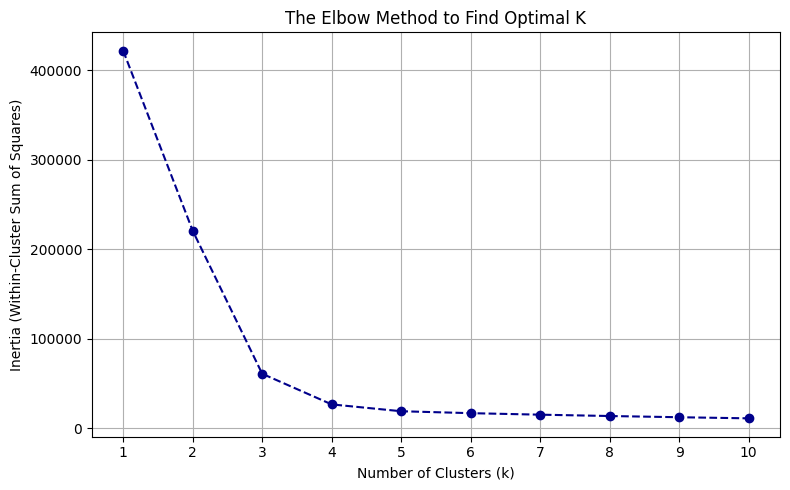

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 1. Generate a self-contained customer dataset with hidden natural clusters
np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=5, cluster_std=1.2, random_state=42)

# Scale features to represent realistic Annual Income ($k) and Spending Scores (1-100)
income = (X[:, 0] - X[:, 0].min()) / (X[:, 0].max() - X[:, 0].min()) * 100 + 15
spending_score = (X[:, 1] - X[:, 1].min()) / (X[:, 1].max() - X[:, 1].min()) * 95 + 5

customer_data = pd.DataFrame({
    'Annual_Income_k': income,
    'Spending_Score': spending_score
})

print("--- Customer Data Preview ---")
print(customer_data.head())
print("\nCalculating inertia for the Elbow Method...")

# 2. Compute the Within-Cluster Sum of Squares (Inertia) for K values from 1 to 10
inertia_values = []
for k in range(1, 11):
    # 'k-means++' ensures smart initial placement of centroids to speed up convergence
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(customer_data)
    inertia_values.append(kmeans.inertia_)

# 3. Plot the Elbow Method Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, marker='o', linestyle='--', color='darkblue')
plt.title('The Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.tight_layout()
plt.show()

--- Customer Segment Profiles (Averages) ---
         Annual_Income_k  Spending_Score
Segment                                 
0                  40.20           15.02
1                  86.90           64.39
2                  61.12           86.32
3                  28.17           78.94
4                 100.18           55.40

Generating Final Market Segmentation Map...


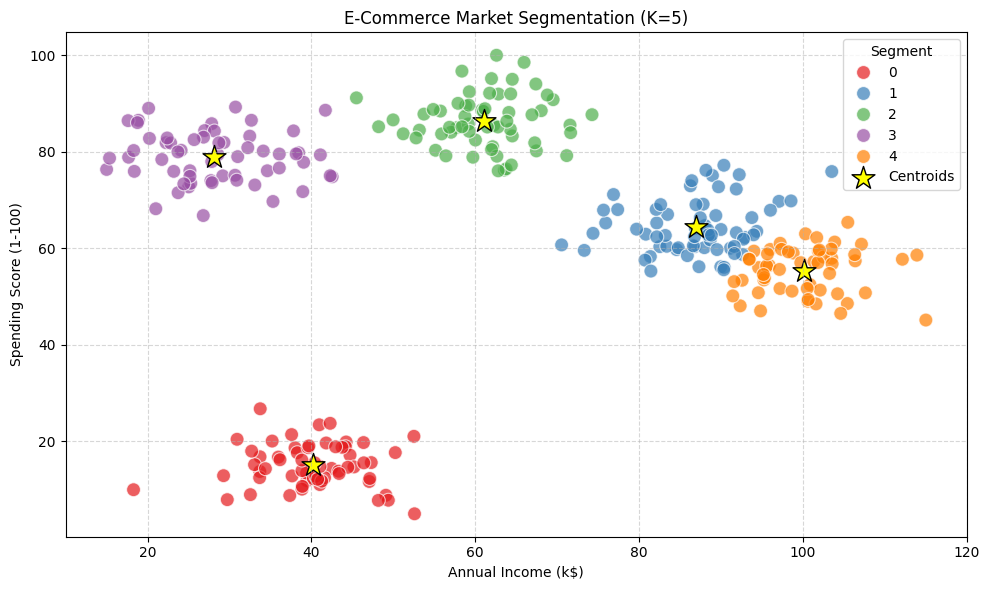

In [2]:
# 1. Train the final K-Means model with our optimal k=5
# 'k-means++' ensures the starting centroids are placed smartly to speed up convergence
kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)

# 2. Assign the mathematical cluster labels back to our original dataset
customer_data['Segment'] = kmeans_final.fit_predict(customer_data)

# 3. Analyze the Clusters: Calculate the average Income and Spending Score per group
cluster_profiles = customer_data.groupby('Segment').mean().round(2)
print("--- Customer Segment Profiles (Averages) ---")
print(cluster_profiles)
print("\nGenerating Final Market Segmentation Map...")

# 4. Visualize the Final Clusters
plt.figure(figsize=(10, 6))

# Plot the individual customers, color-coded by their new segment
sns.scatterplot(
    x='Annual_Income_k',
    y='Spending_Score',
    hue='Segment',
    data=customer_data,
    palette='Set1',
    s=100,
    alpha=0.7,
    legend='full'
)

# Plot the mathematical center (Centroid) of each group in bright yellow
centroids = kmeans_final.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    c='yellow',
    marker='*',
    edgecolors='black',
    label='Centroids'
)

plt.title('E-Commerce Market Segmentation (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Segment')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
from google.colab import files

# Save the segmented data to a CSV
customer_data.to_csv('segmented_customer_data.csv', index=False)

# Trigger a download to your local machine
files.download('segmented_customer_data.csv')
print('CSV file exported successfully!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV file exported successfully!


## Final Project Summary: Market Segmentation Results

Based on the K-Means clustering analysis, we have successfully identified **5 distinct customer segments**:

1.  **Segment 0 (Low Income, Low Spending):** Frugal consumers who are cautious with their spending.
2.  **Segment 1 (High Income, Moderate Spending):** Stable, high-earning customers who likely prioritize value over luxury.
3.  **Segment 2 (Average Income, High Spending):** Highly engaged customers who spend a large portion of their income (Primary target for loyalty programs).
4.  **Segment 3 (Low Income, High Spending):** Often younger or impulsive spenders who prioritize trends despite lower income levels.
5.  **Segment 4 (High Income, High Spending):** The 'Elite' segment—high earners with high spending power (Target for premium/luxury offerings).

### Technical Completion Checklist:
- [x] Synthetic Data Generation (Blobs)
- [x] Feature Scaling for Realism
- [x] Elbow Method for Hyperparameter Optimization ($K=5$)
- [x] Cluster Profiling & Centroid Visualization